# Lab U2_L3: Simple and Multiple Linear Regression

Copy this notebook to `Students/<YourStudentID>/Laboratories/U2_L3.ipynb`. Complete the TODO cells, write your explanations in `U2_L3_Analysis.md`, then restart and run all cells.

Full instructions: `ML_U2_L3_Lab.md`. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes, fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## Part A: Simple OLS on Diabetes BMI

Use the `bmi` feature to predict the quantitative disease-progression target.

In [2]:
diabetes = load_diabetes()

# Print data shape, target shape, and feature names
print(f"Data shape: {diabetes.data.shape}")
print(f"Target shape: {diabetes.target.shape}")
print(f"Feature names: {diabetes.feature_names}")

# Find the bmi column and extract as 1D array x
bmi_index = diabetes.feature_names.index('bmi')
x = diabetes.data[:, bmi_index]
y = diabetes.target

Data shape: (442, 10)
Target shape: (442,)
Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


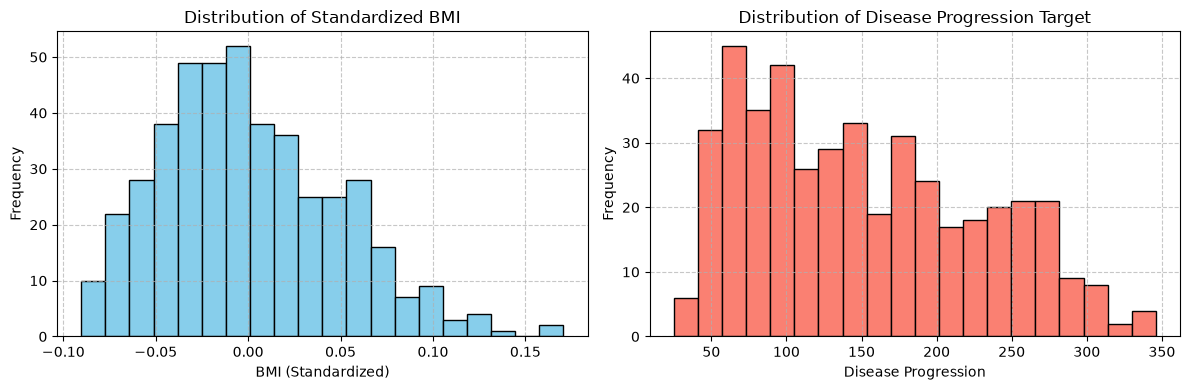

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# BMI Histogram
axes[0].hist(x, bins=20, color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of Standardized BMI')
axes[0].set_xlabel('BMI (Standardized)')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, linestyle='--', alpha=0.7)

# Disease Progression Histogram
axes[1].hist(y, bins=20, color='salmon', edgecolor='black')
axes[1].set_title('Distribution of Disease Progression Target')
axes[1].set_xlabel('Disease Progression')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

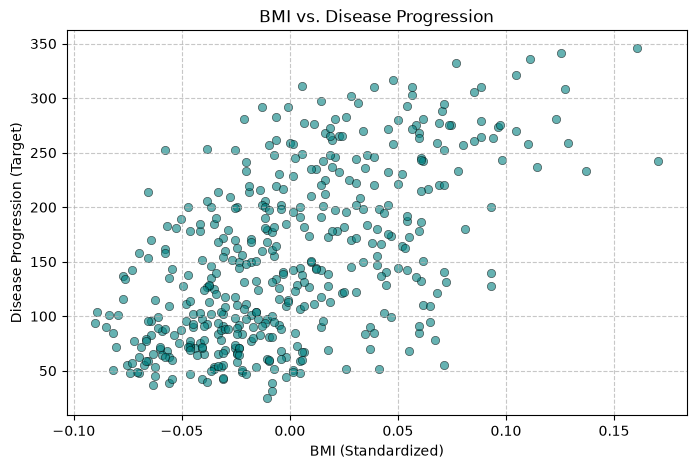

In [4]:
plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.6, color='teal', edgecolors='k', linewidth=0.5)
plt.title('BMI vs. Disease Progression')
plt.xlabel('BMI (Standardized)')
plt.ylabel('Disease Progression (Target)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Formulas for simple OLS

$$\bar{x}=\frac{1}{N}\sum_i x_i, \qquad \bar{y}=\frac{1}{N}\sum_i y_i$$

$$\hat{\beta}_1=\frac{\sum_i(x_i-\bar{x})(y_i-\bar{y})}{\sum_i(x_i-\bar{x})^2}, \qquad \hat{\beta}_0=\bar{y}-\hat{\beta}_1\bar{x}$$

$$\hat y_i=\hat{\beta}_0+\hat{\beta}_1x_i, \qquad e_i=y_i-\hat y_i$$

In [5]:
# Compute means and OLS coefficients using np.mean and array arithmetic only
x_bar = np.mean(x)
y_bar = np.mean(y)

beta_1_hand = np.sum((x - x_bar) * (y - y_bar)) / np.sum((x - x_bar)**2)
beta_0_hand = y_bar - beta_1_hand * x_bar

y_pred_hand = beta_0_hand + beta_1_hand * x
residuals_hand = y - y_pred_hand

print(f"Hand-calculated Intercept (beta_0): {beta_0_hand:.4f}")
print(f"Hand-calculated Slope (beta_1):     {beta_1_hand:.4f}")

Hand-calculated Intercept (beta_0): 152.1335
Hand-calculated Slope (beta_1):     949.4353


### Formula for fit quality

$$SSE=\sum_i(y_i-\hat y_i)^2, \qquad SST=\sum_i(y_i-\bar y)^2, \qquad R^2=1-\frac{SSE}{SST}$$

In [6]:
X_simple = x.reshape(-1, 1)
model_simple = LinearRegression()
model_simple.fit(X_simple, y)

# Assert coefficient and prediction agreement
assert np.allclose([beta_0_hand, beta_1_hand], [model_simple.intercept_, model_simple.coef_[0]]), "Coefficients do not match!"
assert np.allclose(y_pred_hand, model_simple.predict(X_simple)), "Predictions do not match!"

# Calculate SSE, SST, and R^2
sse = np.sum(residuals_hand ** 2)
sst = np.sum((y - y_bar) ** 2)
r2_hand = 1 - (sse / sst)

# Confirm with r2_score
r2_sklearn = r2_score(y, y_pred_hand)
assert np.isclose(r2_hand, r2_sklearn), "R^2 values do not match!"

print(f"SSE: {sse:.4f}")
print(f"SST: {sst:.4f}")
print(f"Hand R^2:    {r2_hand:.4f}")
print(f"Sklearn R^2: {r2_sklearn:.4f}")

SSE: 1719581.8108
SST: 2621009.1244
Hand R^2:    0.3439
Sklearn R^2: 0.3439


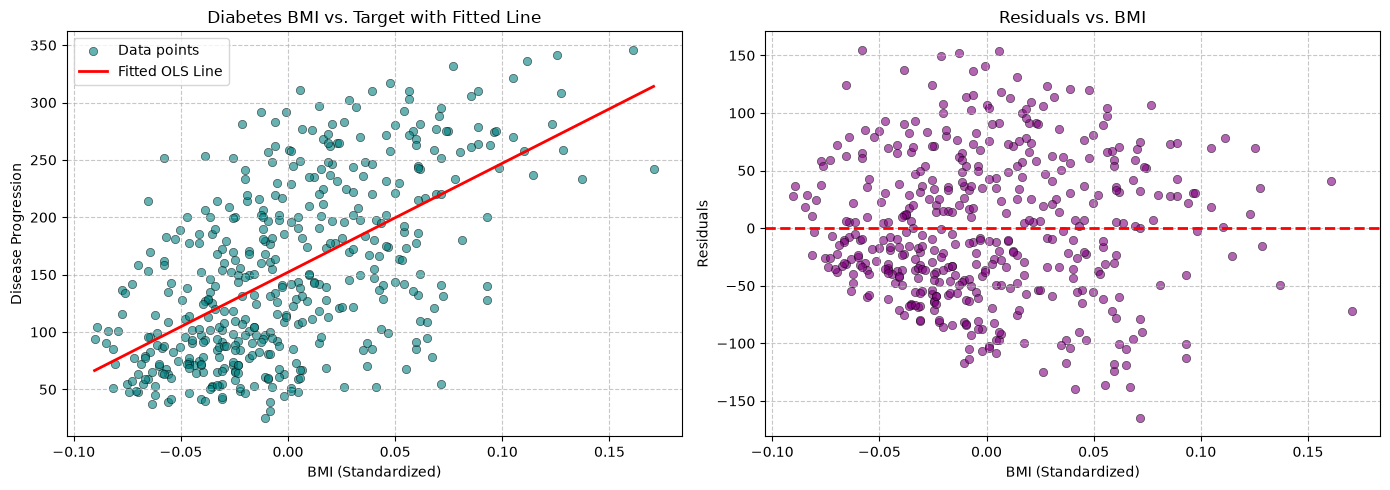

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fitted OLS Line Plot (x sorted for smooth line plot)
axes[0].scatter(x, y, alpha=0.6, label='Data points', color='teal', edgecolors='k', linewidth=0.5)
sort_idx = np.argsort(x)
axes[0].plot(x[sort_idx], y_pred_hand[sort_idx], color='red', linewidth=2, label='Fitted OLS Line')
axes[0].set_title('Diabetes BMI vs. Target with Fitted Line')
axes[0].set_xlabel('BMI (Standardized)')
axes[0].set_ylabel('Disease Progression')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# Residual Plot
axes[1].scatter(x, residuals_hand, alpha=0.6, color='purple', edgecolors='k', linewidth=0.5)
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Residuals vs. BMI')
axes[1].set_xlabel('BMI (Standardized)')
axes[1].set_ylabel('Residuals')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Part B: Multiple regression on California Housing

Explore every feature, choose three predictors from visual evidence, then compare normal equations with scikit-learn.

In [8]:
housing = fetch_california_housing()
y_housing = housing.target

print(f"Data shape: {housing.data.shape}")
print(f"Target shape: {y_housing.shape}")
print(f"All feature names: {housing.feature_names}")

# Three selected features based on visual evidence
selected_features = ['MedInc', 'HouseAge', 'AveRooms']
selected_indices = [housing.feature_names.index(f) for f in selected_features]
X_housing = housing.data[:, selected_indices]

Data shape: (20640, 8)
Target shape: (20640,)
All feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


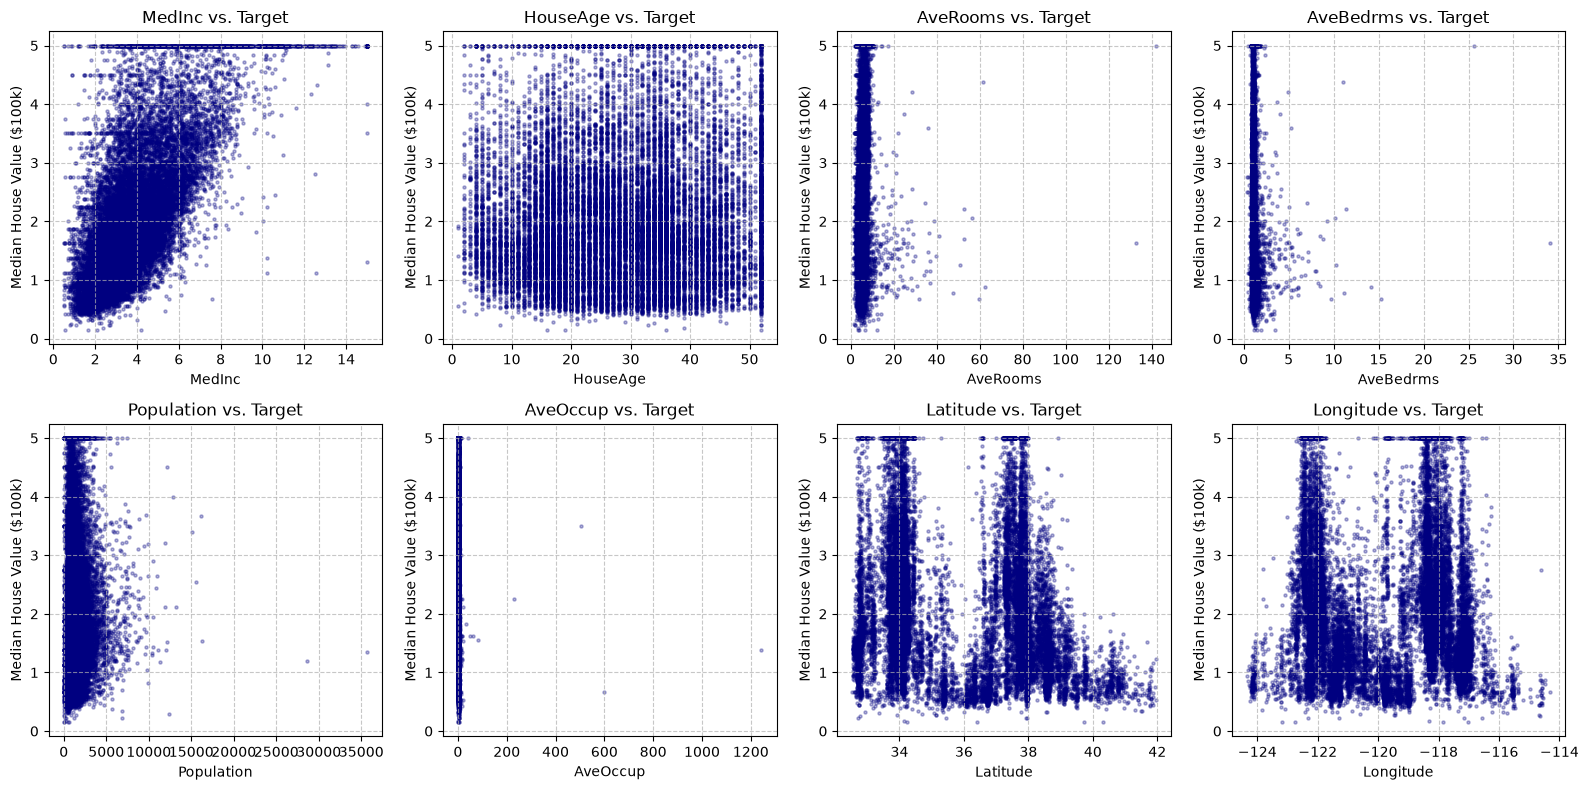

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i, name in enumerate(housing.feature_names):
    axes[i].scatter(housing.data[:, i], y_housing, alpha=0.3, s=5, color='navy')
    axes[i].set_title(f'{name} vs. Target')
    axes[i].set_xlabel(name)
    axes[i].set_ylabel('Median House Value ($100k)')
    axes[i].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Formulas for multiple OLS

Add an intercept column: $$\mathbf{X}_b=[\mathbf{1}\;\mathbf{X}]$$

Solve: $$(\mathbf{X}_b^T\mathbf{X}_b)\hat{\boldsymbol\beta}=\mathbf{X}_b^T\mathbf{y}$$

Do not calculate an explicit inverse to estimate coefficients.

In [10]:
def solve_ols(X, y):
    # Add intercept column
    X_b = np.c_[np.ones(X.shape[0]), X]
    # Solve normal equations: (X_b^T @ X_b) beta = X_b^T @ y using np.linalg.solve
    beta = np.linalg.solve(X_b.T @ X_b, X_b.T @ y)
    return beta, X_b

beta_manual, X_b = solve_ols(X_housing, y_housing)
y_pred_manual = X_b @ beta_manual

print("Manual Beta Parameters [Intercept, MedInc, HouseAge, AveRooms]:")
print(beta_manual)

Manual Beta Parameters [Intercept, MedInc, HouseAge, AveRooms]:
[ 0.02040696  0.4427634   0.01682208 -0.02715343]


In [11]:
model_multiple = LinearRegression()
model_multiple.fit(X_housing, y_housing)

# Sklearn beta with intercept first
beta_sklearn = np.hstack([model_multiple.intercept_, model_multiple.coef_])
y_pred_sklearn = model_multiple.predict(X_housing)

# Assertions
assert np.allclose(beta_manual, beta_sklearn), "Coefficients do not match!"
assert np.allclose(y_pred_manual, y_pred_sklearn), "Predictions do not match!"

print("Sklearn Beta Parameters:")
print(beta_sklearn)
print("Assertions passed: Manual normal equations match scikit-learn!")

Sklearn Beta Parameters:
[ 0.02040696  0.4427634   0.01682208 -0.02715343]
Assertions passed: Manual normal equations match scikit-learn!


### Hat-matrix formulas

$$\mathbf{H}=\mathbf{X}_b(\mathbf{X}_b^T\mathbf{X}_b)^{-1}\mathbf{X}_b^T$$

$$\hat{\mathbf{y}}=\mathbf{H}\mathbf{y}, \qquad \mathbf{e}=\mathbf{y}-\hat{\mathbf{y}}$$

Use the inverse only to construct the hat matrix, as requested here, not to estimate the coefficient vector.

In [12]:
# Construct hat matrix H = X_b @ inv(X_b.T @ X_b) @ X_b.T
H = X_b @ np.linalg.inv(X_b.T @ X_b) @ X_b.T

# Verify symmetry and idempotency
assert np.allclose(H, H.T), "Hat matrix is not symmetric!"
assert np.allclose(H @ H, H), "Hat matrix is not idempotent!"

# Verify H @ y gives fitted values
assert np.allclose(H @ y_housing, y_pred_manual), "H @ y does not match fitted values!"

residuals_multiple = y_housing - y_pred_manual
print(f"Sum of residuals: {np.sum(residuals_multiple):.6e}")
assert np.isclose(np.sum(residuals_multiple), 0, atol=1e-5), "Residuals do not sum to zero!"

# Three largest leverage values and observation indices
leverage = np.diag(H)
top3_idx = np.argsort(leverage)[-3:][::-1]

print("\nThree largest leverage values:")
for idx in top3_idx:
    print(f"Observation Index: {idx:5d} | Leverage Value: {leverage[idx]:.6f}")

Sum of residuals: 3.410605e-11

Three largest leverage values:
Observation Index:  1914 | Leverage Value: 0.169914
Observation Index:  1979 | Leverage Value: 0.144973
Observation Index: 12447 | Leverage Value: 0.030067


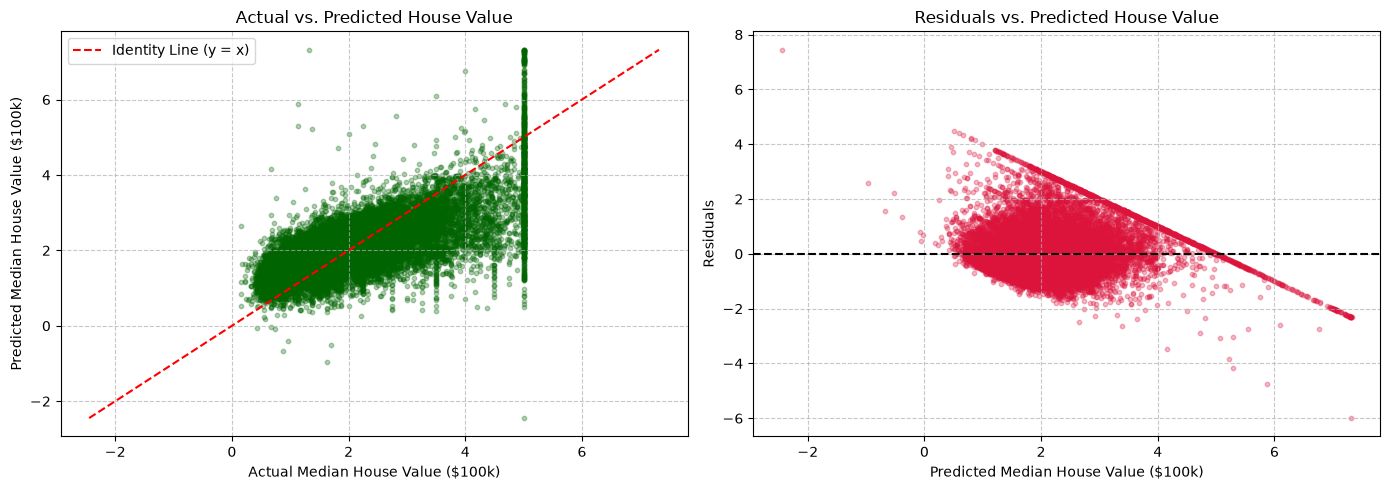

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_housing, y_pred_manual, alpha=0.3, s=10, color='darkgreen')
min_val = min(y_housing.min(), y_pred_manual.min())
max_val = max(y_housing.max(), y_pred_manual.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', label='Identity Line (y = x)')
axes[0].set_title('Actual vs. Predicted House Value')
axes[0].set_xlabel('Actual Median House Value ($100k)')
axes[0].set_ylabel('Predicted Median House Value ($100k)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# Residuals vs Predicted
axes[1].scatter(y_pred_manual, residuals_multiple, alpha=0.3, s=10, color='crimson')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_title('Residuals vs. Predicted House Value')
axes[1].set_xlabel('Predicted Median House Value ($100k)')
axes[1].set_ylabel('Residuals')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Written analysis

Complete `U2_L3_Analysis.md` using the four headings and required questions in `ML_U2_L3_Lab.md`. Cite visible evidence from your plots.

## Final check

Select the Unit II `.venv` kernel, use **Restart**, then **Run All**. Submit both `U2_L3.ipynb` and `U2_L3_Analysis.md`.